In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Percentiles

In [3]:
(75/100)*5

3.75

In [4]:
3/5

0.6

In [5]:
4/5

0.8

In [6]:
(30/100)*9

2.6999999999999997

In [7]:
3/9

0.3333333333333333

In [8]:
2/9

0.2222222222222222

In [9]:
45/100*9

4.05

In [10]:
89/100*9

8.01

In [11]:
percentile(30, make_array(4, 11, 12, 13, 15, 17, 18, 23, 24))

12

In [12]:
percentile(89, make_array(4, 11, 12, 13, 15, 17, 18, 23, 24))

24

In [14]:
nums = make_array(8, 6, 7, 5, 3, 0, 9)
np.sort(nums) # this does *not* change nums

array([0, 3, 5, 6, 7, 8, 9])

In [15]:
nums

array([8, 6, 7, 5, 3, 0, 9])

In [16]:
percentile(75, np.sort(nums))

8

In [18]:
percentile(75, nums)

8

In [19]:
percentile(25, nums)

3

In [20]:
percentile(50, make_array(1, 1, 3, 5, 7, 8, 10, 11, 11, 15))

7

In [21]:
np.median(make_array(1, 1, 3, 5, 7, 8, 10, 11, 11, 15))

7.5

In [24]:
percentile(50, make_array(4, 5, 6, 7, 8, 11))

6

# Bootstrapping

In [26]:
# it's almost never possible to have the entire population, but we're going to practice to one
# all we usually get are samples
population = Table.read_table('data/san_francisco_2019.csv')
population.sample(10)

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Juvenile Court,Correction & Detention,"Counselor, Juvenile Hall PERS",86644,6780,46938,140362
"Public Works, Transportation & Commerce",Municipal Transportation Agcy,Protection & Apprehension,Parking Control Officer,72559,1145,36077,109781
"Public Works, Transportation & Commerce",Department Of Public Works,Sub-Professional Engineering,"StdntDsgnTrain1, Arch/Eng/Plng",25824,0,2004,27828
Community Health,Public Health,"Clerical, Secretarial & Steno",Clerk,53803,0,31884,85687
General Administration & Finance,Human Resources,"Budget, Admn & Stats Analysis",Management Assistant,86647,0,39419,126066
Culture & Recreation,Recreation And Park Commission,Recreation,Swimming Instructor,2874,0,223,3097
Public Protection,Juvenile Court,Probation & Parole,Deputy Probation Officer,45140,3504,11801,60445
General Administration & Finance,City Attorney,"Clerical, Secretarial & Steno",Legal Secretary 1,90586,0,39997,130583
"Public Works, Transportation & Commerce",Municipal Transportation Agcy,Street Transit,Transit Operator,56394,7941,33409,97743
Public Protection,Fire Department,Fire Services,EMT/Paramedic/Firefighter,156878,61,50493,207432


In [28]:
population.sort('Total Compensation', descending=True)

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
General Administration & Finance,Retirement Services,Administrative & Mgmt (Unrep),Chief Investment Officer,577633,0,146398,724031
General Administration & Finance,Retirement Services,Unassigned,Managing Director,483072,0,134879,617951
General Administration & Finance,Retirement Services,Unassigned,Managing Director,482649,0,134905,617554
General Administration & Finance,Retirement Services,Unassigned,Managing Director,451507,0,120276,571784
General Administration & Finance,Retirement Services,Unassigned,Managing Director,449378,0,120857,570235
Community Health,Public Health,Administrative & Mgmt (Unrep),"Physician Administrator, DPH",434966,0,119213,554179
Public Protection,Sheriff,Correction & Detention,Senior Deputy Sheriff,152153,315896,77275,545324
General Administration & Finance,Retirement Services,Management,Director,397392,0,108913,506305
Community Health,Public Health,Medical & Dental,Supervising Physician Spec,404701,0,99480,504181
Community Health,Public Health,Medical & Dental,Senior Physician Specialist,400992,0,97428,498421


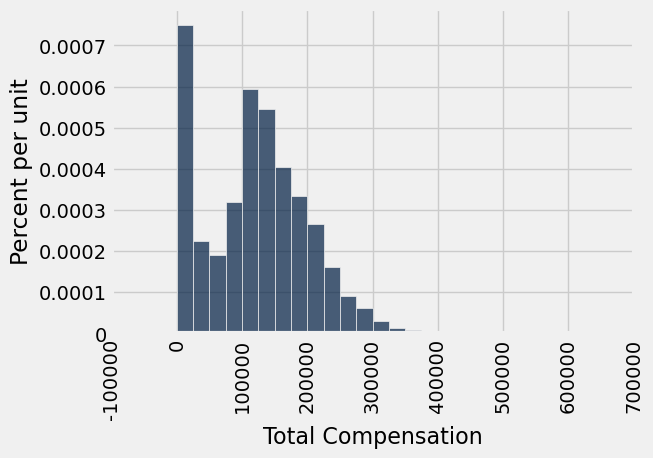

In [31]:
population.hist('Total Compensation', bins=np.arange(0, 600000, 25000))

In [32]:
population.sort('Total Compensation')

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Adult Probation,Probation & Parole,Deputy Probation Officer,0,0,0,0
Public Protection,Fire Department,"Clerical, Secretarial & Steno",Senior Clerk Typist,0,0,0,0
Public Protection,Juvenile Court,Correction & Detention,"Counselor, Juvenile Hall PERS",0,0,0,0
Public Protection,Police,"Clerical, Secretarial & Steno",Clerk Typist,0,0,0,0
Public Protection,Sheriff,Correction & Detention,Deputy Sheriff,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,Sub-Professional Engineering,StdntDsgn Train2/Arch/Eng/Plng,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,"Clerical, Secretarial & Steno",Executive Secretary 1,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,"Payroll, Billing & Accounting",Senior Account Clerk,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,Housekeeping & Laundry,Custodian,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,Housekeeping & Laundry,Custodian,0,0,0,0


In [33]:
min_salary = 15 * 20 * 50  # min. wage was $15, part time, 2 weeks of vacation
min_salary

15000

In [34]:
population = population.where('Salary', are.above_or_equal_to(min_salary))
population

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Adult Probation,Information Systems,IS Trainer-Journey,91332,0,40059,131391
Public Protection,Adult Probation,Information Systems,IS Engineer-Assistant,123241,0,49279,172520
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Senior,115715,0,46752,162468
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Principal,159394,0,57312,216706
Public Protection,Adult Probation,Information Systems,IS Programmer Analyst,70035,0,28671,98706
Public Protection,Adult Probation,Information Systems,IS Project Director,175742,0,60830,236572
Public Protection,Adult Probation,Information Systems,IT Operations Support Admin IV,123840,0,49429,173269
Public Protection,Adult Probation,"Payroll, Billing & Accounting",Accountant III,111816,0,46319,158135
Public Protection,Adult Probation,"Budget, Admn & Stats Analysis",Statistician,87725,0,38899,126624
Public Protection,Adult Probation,"Budget, Admn & Stats Analysis",Senior Administrative Analyst,116192,0,47651,163843


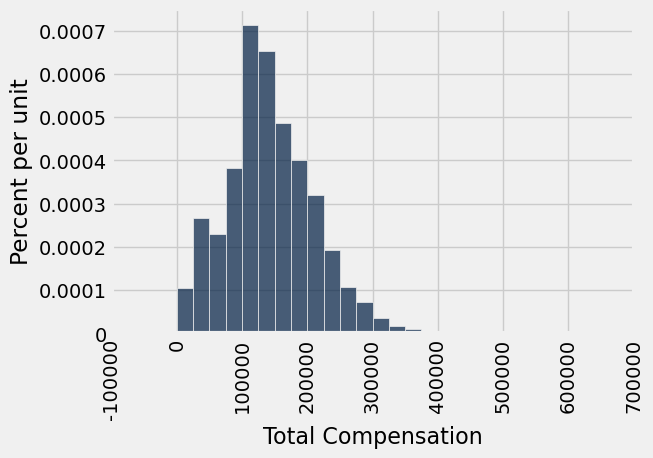

In [35]:
population.hist('Total Compensation', bins=np.arange(0, 600000, 25000))

In [37]:
pop_median = percentile(50, population.column('Total Compensation'))
pop_median

135747.0

In [38]:
# np.median works too!
np.median(population.column('Total Compensation'))

135747.0

## Let's pretend we took a sample of 400 people, and that's all we have

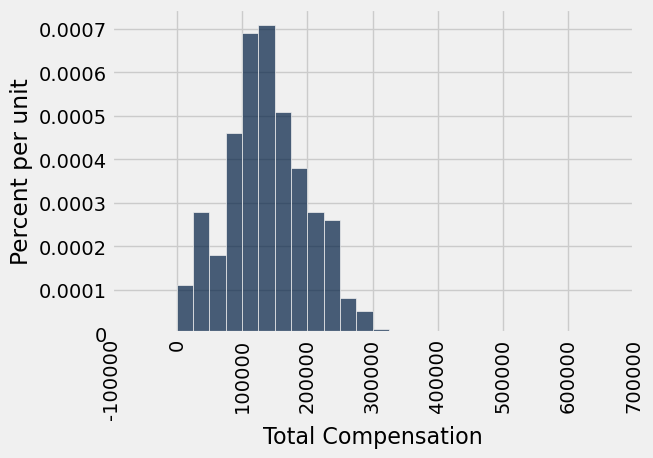

In [39]:
sample_size = 400
sample = population.sample(sample_size, with_replacement=False) # 400 separate people
sample.hist('Total Compensation', bins=np.arange(0, 600000, 25000))

In [40]:
percentile(50, sample.column('Total Compensation'))

130777.0

132854.0

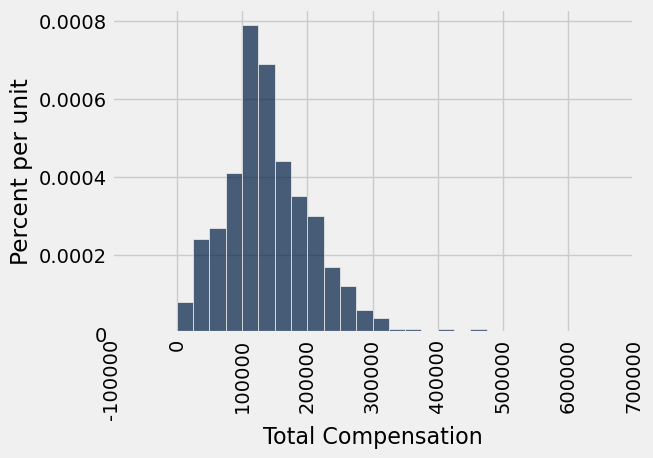

In [43]:
# usually, you can't get another sample like this!
sample_size = 400
sample2 = population.sample(sample_size, with_replacement=False) # 400 separate people
sample2.hist('Total Compensation', bins=np.arange(0, 600000, 25000))
percentile(50, sample2.column('Total Compensation'))

In [53]:
resample = sample.sample(sample.num_rows, with_replacement=True) # sample.sample() would work here
percentile(50, resample.column('Total Compensation'))

132779.0

In [54]:
def one_bootstrap_median():
    # draw the bootstrap sample
    resample = sample.sample(sample.num_rows, with_replacement=True) # sample.sample() would work here
    # return the median total comp. in the bootstrap sample
    return percentile(50, resample.column('Total Compensation'))

In [55]:
bootstrapped_sample_medians = make_array()
num_resamples = 1000

for i in np.arange(num_resamples):
    new_median = one_bootstrap_median()
    bootstrapped_sample_medians = np.append(bootstrapped_sample_medians, new_median)

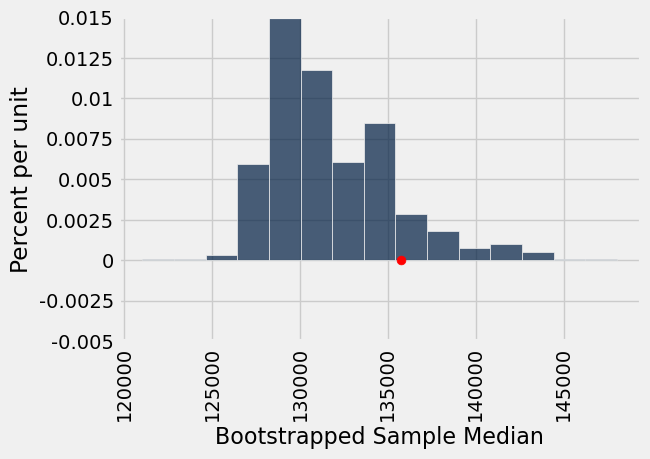

In [58]:
bootstrapped_median_table = Table().with_column('Bootstrapped Sample Median', bootstrapped_sample_medians)
bootstrapped_median_table.hist(bins=15)

plt.ylim(-0.00005, 0.00015)
plt.scatter(pop_median, 0, color='red', s=40);

In [59]:
# middle 95% of our estimates gives us an estimate that's correct 95% of the time
# 2.5% -- 97.5% is the range we want here -- that's the middle 95%
# called a *confidence interval*
percentile(2.5, bootstrapped_sample_medians), percentile(97.5, bootstrapped_sample_medians)

(126684.0, 141365.0)

In [60]:
# 90% confidence interval
percentile(5, bootstrapped_sample_medians), percentile(95, bootstrapped_sample_medians)

(127341.0, 138017.0)

In [61]:
population_mean = population.column('Total Compensation').mean()
population_mean

142675.017788319

In [ ]:
# Crushed ICE: using boostrap sampling and our size 400 sample, 
# calculate a 95% confidence interval for the average total comp.